In [1]:
import pandas as pd
import numpy as np

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
file_path = r"C:\Users\91895\OneDrive\Desktop\NeuralRetail\data\raw\online+retail+ii\online_retail_II.xlsx"

In [5]:
df_2009 = pd.read_excel(
    file_path,
    sheet_name="Year 2009-2010"
)

df_2010 = pd.read_excel(
    file_path,
    sheet_name="Year 2010-2011"
)

df = pd.concat(
    [df_2009, df_2010],
    ignore_index=True
)

print(df.shape)

(1067371, 8)


In [6]:
import os

os.makedirs(
    r"C:\Users\91895\OneDrive\Desktop\NeuralRetail\data\processed",
    exist_ok=True
)

In [7]:
df = pd.read_csv(
    r"C:\Users\91895\OneDrive\Desktop\NeuralRetail\data\processed\cleaned_retail.csv"
)

In [8]:
print(df.shape)
df.head()

(805549, 9)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [9]:
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"]
)

In [10]:
snapshot_date = (
    df["InvoiceDate"].max()
    + pd.Timedelta(days=1)
)

snapshot_date

Timestamp('2011-12-10 12:50:00')

In [11]:
rfm = df.groupby(
    "Customer ID"
).agg({
    "InvoiceDate": lambda x:
        (snapshot_date - x.max()).days,

    "Invoice": "nunique",

    "Revenue": "sum"
})

In [12]:
rfm.columns = [
    "Recency",
    "Frequency",
    "Monetary"
]

In [13]:
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,12,77556.46
12347.0,2,8,5633.32
12348.0,75,5,2019.40
12349.0,19,4,4428.69
12350.0,310,1,334.40


In [15]:
rfm.describe()

,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000
mean,201.331916,6.289384,3018.616737
std,209.338707,13.009406,14737.731040
min,1.000000,1.000000,2.950000
25%,26.000000,1.000000,348.762500
50%,96.000000,3.000000,898.915000
75%,380.000000,7.000000,2307.090000
max,739.000000,398.000000,608821.650000


In [16]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm
)

In [17]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

In [18]:
rfm["Cluster"] = (
    kmeans.fit_predict(
        rfm_scaled
    )
)

In [19]:
rfm["Cluster"].value_counts()

Cluster
1    3841
0    1998
2      35
3       4
Name: count, dtype: int64

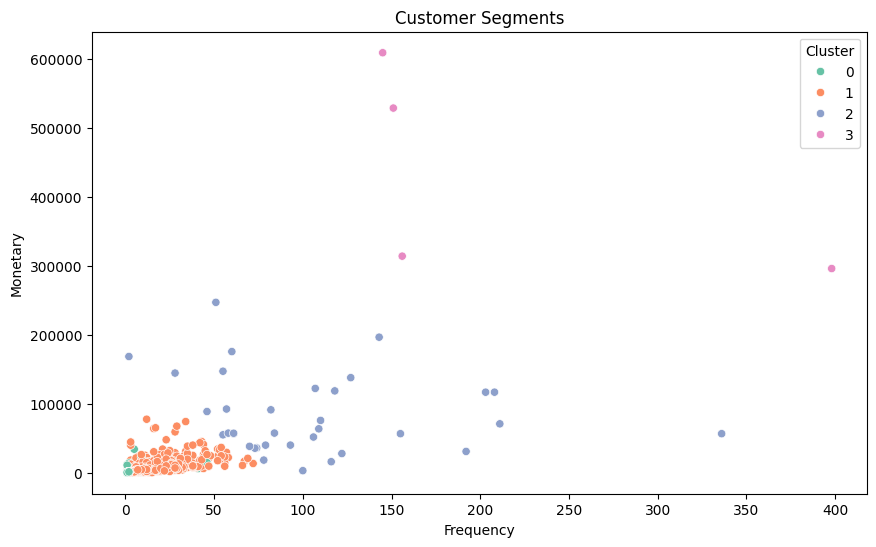

In [20]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="Set2"
)

plt.title(
    "Customer Segments"
)

plt.show()

In [21]:
rfm.groupby("Cluster").mean()

,Recency,Frequency,Monetary
Cluster,,,
0,463.032032,2.212212,765.244446
1,67.005728,7.307732,3009.402451
2,25.942857,103.714286,83086.079771
3,3.500000,212.500000,436835.792500


In [26]:
segment_map = {
    0: "At Risk",
    1: "Regular",
    2: "VIP",
    3: "Champions"
}

rfm["Segment"] = rfm["Cluster"].map(segment_map)

In [27]:
rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
Customer ID,,,,,
12346.0,326,12,77556.46,1,Regular
12347.0,2,8,5633.32,1,Regular
12348.0,75,5,2019.40,1,Regular
12349.0,19,4,4428.69,1,Regular
12350.0,310,1,334.40,0,At Risk


In [28]:
rfm["Segment"].value_counts()

Segment
Regular      3841
At Risk      1998
VIP            35
Champions       4
Name: count, dtype: int64

In [25]:
rfm.to_csv(
    r"C:\Users\91895\OneDrive\Desktop\NeuralRetail\data\processed\customer_segments.csv"
)

Key Findings

1. Majority customers belong to Regular segment.
2. Around 2000 customers are At Risk.
3. VIP customers contribute disproportionately to revenue.
4. Champions represent the most valuable customer group.

In [29]:
print(df["InvoiceDate"].min())
print(df["InvoiceDate"].max())

2009-12-01 07:45:00
2011-12-09 12:50:00
